Tensorflow
- we are building a deep learning model 
- minimise loss function (update weights and biases so difference between expected and actual is small)
- 


In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

2026-02-25 23:26:33.287403: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df_merged = pd.read_csv('~/ai-price-predictor/data/eurgbp_moon_phases.csv', index_col=0, parse_dates=True)
df_merged.head()

,Close,High,Low,Open,Category,Phase
Date,,,,,,
2003-08-05,0.7055,0.7078,0.7023,0.7042,2,0.2280
2003-08-06,0.7041,0.7078,0.7030,0.7056,2,0.2620
2003-08-07,0.7032,0.7077,0.7019,0.7041,3,0.2960
2003-08-08,0.7042,0.7056,0.7016,0.7033,3,0.3299
2003-08-11,0.7065,0.7071,0.7032,0.7054,3,0.4318


clean data

In [3]:
df_merged.describe()

,Close,High,Low,Open,Category,Phase
count,5832.000000,5832.000000,5832.000000,5832.000000,5832.000000,5832.000000
mean,0.814469,0.817197,0.811728,0.814474,3.598251,0.500026
std,0.076994,0.077371,0.077356,0.076996,2.329919,0.288638
min,0.654900,0.657000,0.006600,0.654900,0.000000,0.000300
25%,0.762275,0.765655,0.758280,0.762075,2.000000,0.249975
50%,0.845265,0.847740,0.842600,0.845245,4.000000,0.499500
75%,0.871315,0.874110,0.868310,0.871413,5.250000,0.748825
max,0.979000,0.979700,0.967800,0.977500,7.000000,0.999900


In [4]:
# Convert datetime index to numerical values (timestamp in seconds since epoch)
df_merged['Timestamp'] = df_merged.index.astype(np.int64) // 10**9
df_merged.head()

,Close,High,Low,Open,Category,Phase,Timestamp
Date,,,,,,,
2003-08-05,0.7055,0.7078,0.7023,0.7042,2,0.2280,1060041600
2003-08-06,0.7041,0.7078,0.7030,0.7056,2,0.2620,1060128000
2003-08-07,0.7032,0.7077,0.7019,0.7041,3,0.2960,1060214400
2003-08-08,0.7042,0.7056,0.7016,0.7033,3,0.3299,1060300800
2003-08-11,0.7065,0.7071,0.7032,0.7054,3,0.4318,1060560000


In [5]:
# Clean df_merged: drop duplicates, handle missing values, convert types, remove simple outliers
# Ensure datetime index
df_merged.index = pd.to_datetime(df_merged.index)

# Drop exact duplicate rows
before = len(df_merged)
df_merged = df_merged[~df_merged.duplicated(keep='first')]
# Drop duplicated index entries (keep first)
df_merged = df_merged[~df_merged.index.duplicated(keep='first')]
after_dups = len(df_merged)

print(f"Rows before duplicates: {before}, after duplicates: {after_dups}")

# Forward-fill OHLC price columns then drop any rows without Close
price_cols = [c for c in ['Open', 'High', 'Low', 'Close'] if c in df_merged.columns]
if price_cols:
    df_merged[price_cols] = df_merged[price_cols].ffill()

# Drop rows missing Close price (essential)
df_merged = df_merged.dropna(subset=['Close'])

# Convert Category and Phase to numeric types
if 'Category' in df_merged.columns:
    df_merged['Category'] = pd.to_numeric(df_merged['Category'], errors='coerce').astype('Int64')
if 'Phase' in df_merged.columns:
    df_merged['Phase'] = pd.to_numeric(df_merged['Phase'], errors='coerce')

print(df_merged.head())

# Ensure a numeric timestamp column exists (seconds since epoch)
if 'Timestamp' not in df_merged.columns:
    df_merged['Timestamp'] = df_merged.index.astype('int64') // 10**9

# Save cleaned CSV
out_path = '~/ai-price-predictor/data/eurgbp_moon_phases_cleaned.csv'
df_merged.to_csv(out_path)

# Summary
print(f"Rows before duplicates: {before}, after duplicates: {after_dups}, after cleaning: {len(df_merged)}")
print('\nMissing values per column:')
print(df_merged.isna().sum())

df_merged.info()

df_merged.head()

Rows before duplicates: 5832, after duplicates: 5832
             Close    High     Low    Open  Category   Phase   Timestamp
Date                                                                    
2003-08-05  0.7055  0.7078  0.7023  0.7042         2  0.2280  1060041600
2003-08-06  0.7041  0.7078  0.7030  0.7056         2  0.2620  1060128000
2003-08-07  0.7032  0.7077  0.7019  0.7041         3  0.2960  1060214400
2003-08-08  0.7042  0.7056  0.7016  0.7033         3  0.3299  1060300800
2003-08-11  0.7065  0.7071  0.7032  0.7054         3  0.4318  1060560000
Rows before duplicates: 5832, after duplicates: 5832, after cleaning: 5832

Missing values per column:
Close        0
High         0
Low          0
Open         0
Category     0
Phase        0
Timestamp    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5832 entries, 2003-08-05 to 2025-12-29
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Close 

,Close,High,Low,Open,Category,Phase,Timestamp
Date,,,,,,,
2003-08-05,0.7055,0.7078,0.7023,0.7042,2,0.2280,1060041600
2003-08-06,0.7041,0.7078,0.7030,0.7056,2,0.2620,1060128000
2003-08-07,0.7032,0.7077,0.7019,0.7041,3,0.2960,1060214400
2003-08-08,0.7042,0.7056,0.7016,0.7033,3,0.3299,1060300800
2003-08-11,0.7065,0.7071,0.7032,0.7054,3,0.4318,1060560000


split the data
(70%, 20%, 10%) split for the training, validation, and test sets.
- we dont want to random split, we want chronolical split
- don't scale before splitting

In [48]:
column_indices = {name: i for i, name in enumerate(df_merged.columns)}

n = len(df_merged)
train_df = df_merged[0:int(n*0.7)]
val_df = df_merged[int(n*0.7):int(n*0.9)]
test_df = df_merged[int(n*0.9):]

num_features = df_merged.shape[1]

Normalise the data,
(only normalise using the training data the model doesnt have access to the other data)

 The reason we normailse is due to the model using gradient decent as its method to minimise the loss function. 
 When the coefificeints of the function are scaled differently then it messes up how well the gradient decent can be performed therfore we need to normalise the data so that it is not scaled differently
 The data gets scaled to the right range of around 0-1 so that the nueral net can handle the data properly


In [49]:
# OHLC log returns
train_df["log_return_close"] = np.log(train_df["Close"] / train_df["Close"].shift(1))
train_df["log_return_high"] = np.log(train_df["High"] / train_df["High"].shift(1))
train_df["log_return_low"]  = np.log(train_df["Low"]  / train_df["Low"].shift(1))
train_df["log_return_open"]  = np.log(train_df["Open"]  / train_df["Open"].shift(1))

# Phase normalization
train_df['phase_sin'] = np.sin(2 * np.pi * train_df['Phase'])
train_df['phase_cos'] = np.cos(2 * np.pi * train_df['Phase'])

/var/folders/4k/vfqklwlx0dd1n7989cb17n1h0000gp/T/ipykernel_19411/561833767.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["log_return_close"] = np.log(train_df["Close"] / train_df["Close"].shift(1))
/var/folders/4k/vfqklwlx0dd1n7989cb17n1h0000gp/T/ipykernel_19411/561833767.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["log_return_high"] = np.log(train_df["High"] / train_df["High"].shift(1))
/var/folders/4k/vfqklwlx0dd1n7989cb17n1h0000gp/T/ipykernel_19411/561833767.py:4: SettingW

In [50]:
# remove any rows that contain NaNs (e.g. the first row after computing log‑returns)
train_df = train_df.dropna()
val_df = val_df.dropna()
test_df = test_df.dropna()


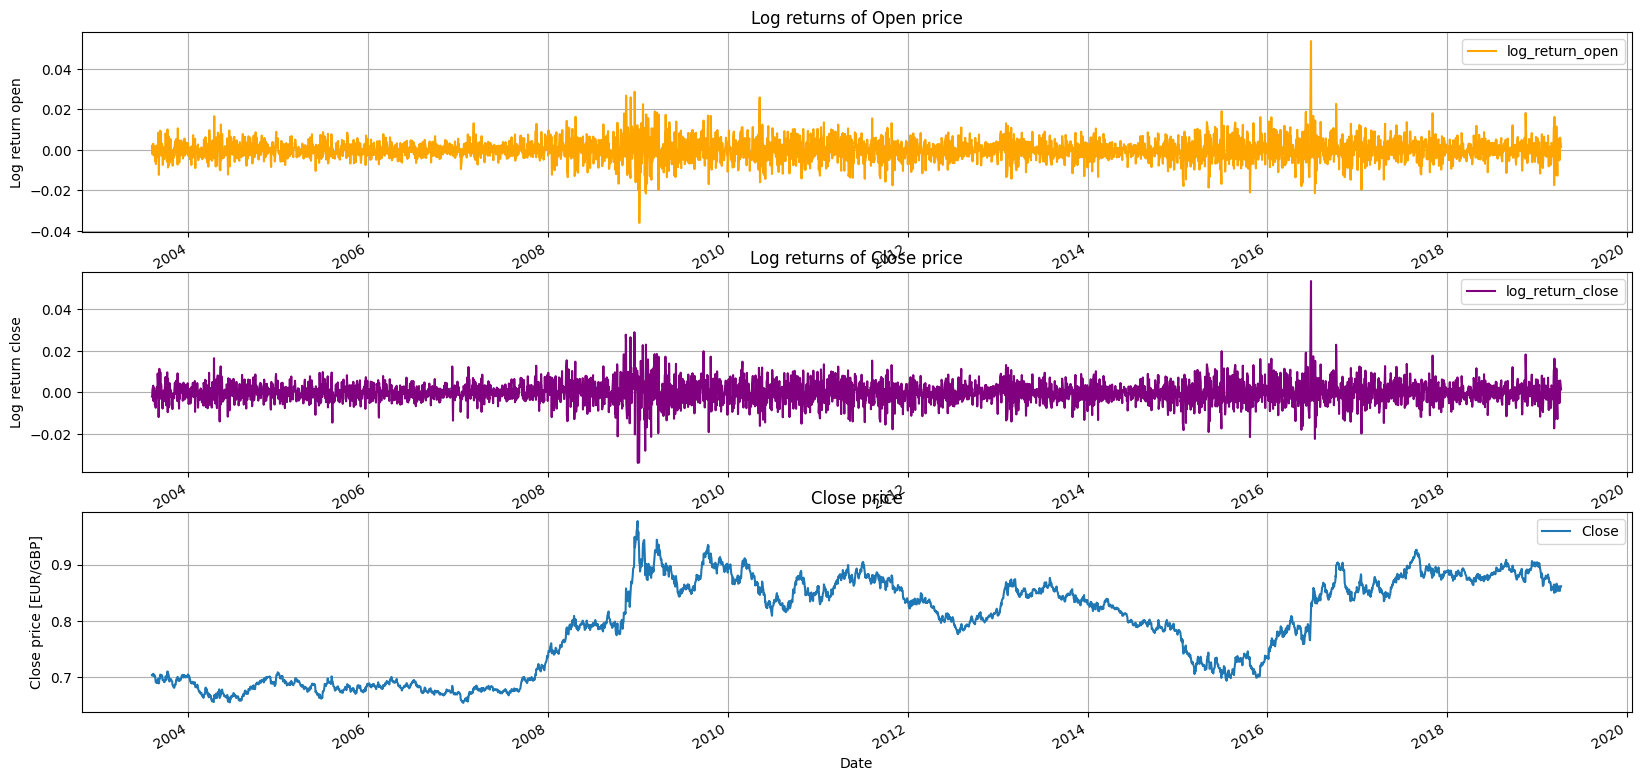

In [51]:
# plot log returns of close and open prices over the training period
fig, axes = plt.subplots(3,1, figsize=(20, 10))
train_df[['log_return_open']].plot(
    title='Log returns of Open price',
    ax=axes[0],
    color='orange'
)
train_df[['log_return_close']].plot(
    title='Log returns of Close price',
    ax=axes[1],
    color='purple'
)
train_df[['Close']].plot(
    title='Close price',
    ax=axes[2]
)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Log return open')
axes[0].grid(True)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Log return close')
axes[1].grid(True)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Close price [EUR/GBP]')
axes[2].grid(True)
plt.show()

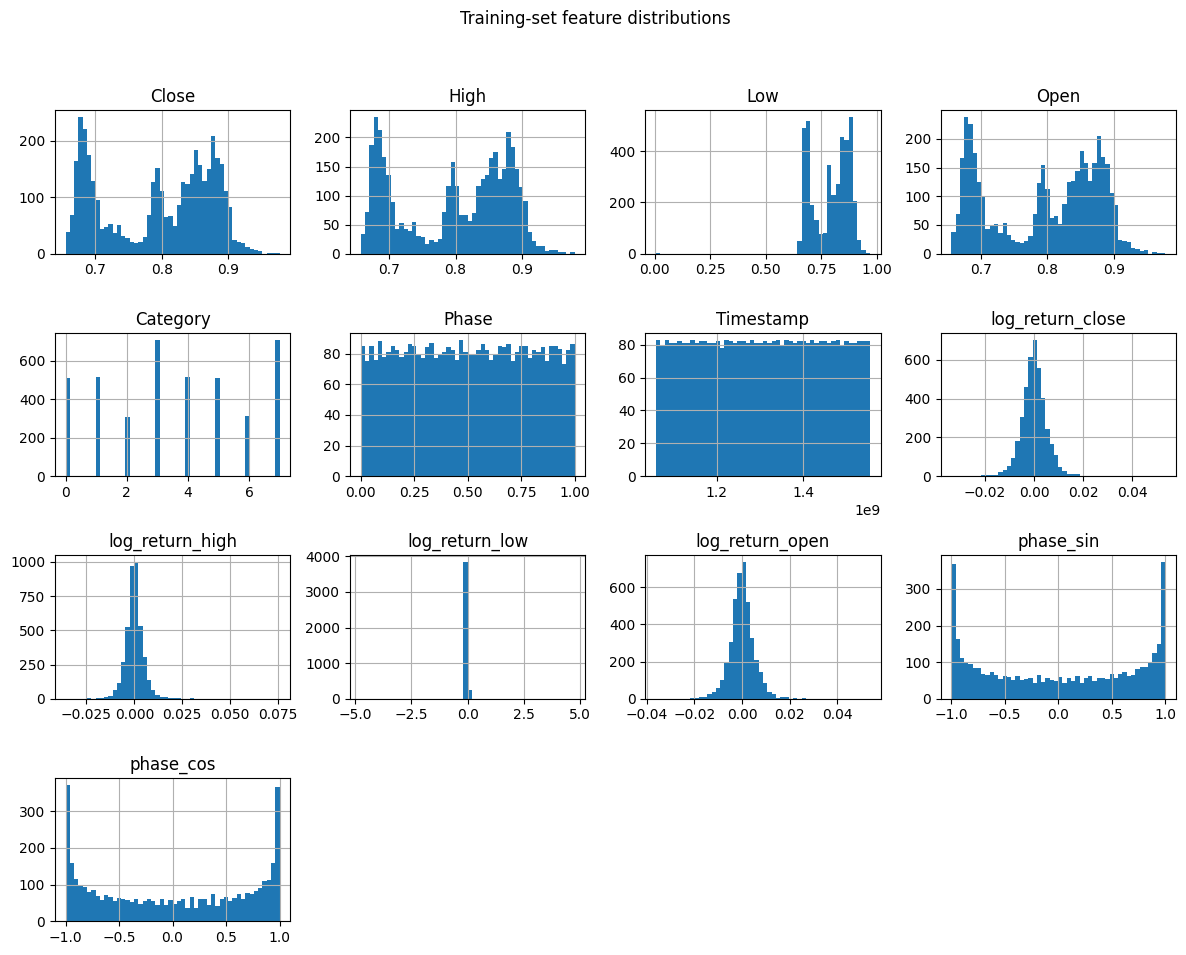

In [52]:
# show distribution of every column in the training set
train_df.hist(figsize=(12, 10), bins=50)
plt.suptitle('Training‑set feature distributions')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [53]:
# Drop unnormalized features (original OHLC and Phase) and keep only the new feature columns (log returns and phase transformations)
train_df_norm = train_df.iloc[:, 6:]
train_df_norm.head()

,Timestamp,log_return_close,log_return_high,log_return_low,log_return_open,phase_sin,phase_cos
Date,,,,,,,
2003-08-06,1060128000,-0.001986,0.000000,0.000996,0.001986,0.997159,-0.075327
2003-08-07,1060214400,-0.001279,-0.000141,-0.001566,-0.002128,0.958522,-0.285019
2003-08-08,1060300800,0.001421,-0.002972,-0.000427,-0.001137,0.876609,-0.481203
2003-08-11,1060560000,0.003261,0.002124,0.002278,0.002981,0.415519,-0.909585
2003-08-12,1060646400,-0.004113,0.000283,-0.000142,0.000425,0.213235,-0.977001


WindowGenerator
- splits up the data into sections of time so that
- a predicton is made based on window of consecutive datapoints 
features of a window:
- width = number of timesteps in the window
- time offset between each window

In [10]:
class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df=train_df, val_df=val_df, test_df=test_df,
               label_columns=None):
    # Store the raw data.
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    # Work out the label column indices.
    self.label_columns = label_columns
    if label_columns is not None:
      self.label_columns_indices = {name: i for i, name in
                                    enumerate(label_columns)}
    self.column_indices = {name: i for i, name in
                           enumerate(train_df.columns)}

    # Work out the window parameters.
    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift

    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]

    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def __repr__(self):
    return '\n'.join([
        f'Total window size: {self.total_window_size}',
        f'Input indices: {self.input_indices}',
        f'Label indices: {self.label_indices}',
        f'Label column name(s): {self.label_columns}'])